## Disaster Tweets Classification with Conv1D

In [1]:
import tensorflow as tf
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tensorflow import keras
from sklearn.model_selection import train_test_split
import nltk

In [2]:
class Config:
    vocab_size = 5000
    embed_size = 100
    filters = 256
    num_words = 3
    batch_size = 64
    epochs = 20
    maxlen = 100
    model_path = "model.tf"
    
config = Config() 

In [3]:
train = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
test = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")
sample_submission = pd.read_csv("/kaggle/input/nlp-getting-started/sample_submission.csv")

In [4]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


## Preprocessing

In [6]:
train["sentence_preprocessed"] = train["text"].apply(lambda sentence: " ". join(nltk.word_tokenize(sentence.lower())))
test["sentence_preprocessed"] = test["text"].apply(lambda sentence: " ". join(nltk.word_tokenize(sentence.lower())))

In [7]:
train.head()

,id,keyword,location,text,target,sentence_preprocessed
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,our deeds are the reason of this # earthquake ...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask . canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,all residents asked to 'shelter in place ' are...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,"13,000 people receive # wildfires evacuation o..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,just got sent this photo from ruby # alaska as...


## Text Vectorization

In [8]:
vectorizor = keras.layers.TextVectorization(max_tokens=config.vocab_size)
vectorizor.adapt(list(train["sentence_preprocessed"]) + list(test["sentence_preprocessed"]))


User settings:

   KMP_AFFINITY=granularity=fine,verbose,compact,1,0
   KMP_BLOCKTIME=0
   KMP_DUPLICATE_LIB_OK=True
   KMP_INIT_AT_FORK=FALSE
   KMP_SETTINGS=1
   KMP_WARNINGS=0

Effective settings:

   KMP_ABORT_DELAY=0
   KMP_ADAPTIVE_LOCK_PROPS='1,1024'
   KMP_ALIGN_ALLOC=64
   KMP_ALL_THREADPRIVATE=128
   KMP_ATOMIC_MODE=2
   KMP_BLOCKTIME=0
   KMP_CPUINFO_FILE: value is not defined
   KMP_DETERMINISTIC_REDUCTION=false
   KMP_DEVICE_THREAD_LIMIT=2147483647
   KMP_DISP_NUM_BUFFERS=7
   KMP_DUPLICATE_LIB_OK=true
   KMP_ENABLE_TASK_THROTTLING=true
   KMP_FORCE_REDUCTION: value is not defined
   KMP_FOREIGN_THREADS_THREADPRIVATE=true
   KMP_FORKJOIN_BARRIER='2,2'
   KMP_FORKJOIN_BARRIER_PATTERN='hyper,hyper'
   KMP_GTID_MODE=3
   KMP_HANDLE_SIGNALS=false
   KMP_HOT_TEAMS_MAX_LEVEL=1
   KMP_HOT_TEAMS_MODE=0
   KMP_INIT_AT_FORK=true
   KMP_LIBRARY=throughput
   KMP_LOCK_KIND=queuing
   KMP_MALLOC_POOL_INCR=1M
   KMP_NUM_LOCKS_IN_BLOCK=1
   KMP_PLAIN_BARRIER='2,2'
   KMP_PLAIN_BARRIER_P

## Train Validation Split

In [9]:
x_train, x_val, y_train, y_val = train_test_split(train["sentence_preprocessed"], train["target"], test_size=0.2, random_state=42)
x_train.shape, x_val.shape, y_train.shape, y_val.shape

((6090,), (1523,), (6090,), (1523,))

## Modeling

In [10]:
keras.backend.clear_session()
model = keras.Sequential([
    keras.Input(shape=(None, ), dtype="string"),
    vectorizor,
    keras.layers.Embedding(config.vocab_size, config.embed_size, input_length=config.maxlen),
    keras.layers.SpatialDropout1D(0.2),
    keras.layers.Conv1D(filters=config.filters, kernel_size=config.num_words, activation="relu"),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(1, activation="sigmoid")
])

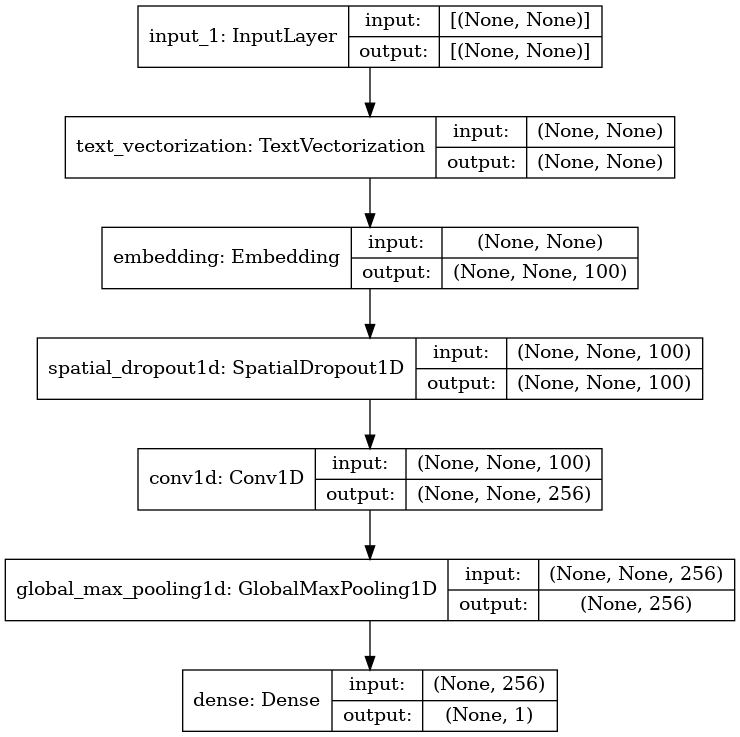

In [11]:
keras.utils.plot_model(model, show_shapes=True)

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
text_vectorization (TextVect (None, None)              0         
_________________________________________________________________
embedding (Embedding)        (None, None, 100)         500000    
_________________________________________________________________
spatial_dropout1d (SpatialDr (None, None, 100)         0         
_________________________________________________________________
conv1d (Conv1D)              (None, None, 256)         77056     
_________________________________________________________________
global_max_pooling1d (Global (None, 256)               0         
_________________________________________________________________
dense (Dense)                (None, 1)                 257       
Total params: 577,313
Trainable params: 577,313
Non-trainable params: 0
__________________________________________________

In [13]:
checkpoint = keras.callbacks.ModelCheckpoint(config.model_path, monitor="val_accuracy", save_best_only=True, save_weights_only=True)
early_stop = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5)
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
histry = model.fit(
    x_train, y_train, 
    batch_size=config.batch_size, 
    epochs=config.epochs,
    validation_data=(x_val, y_val),
    callbacks=[checkpoint, early_stop]
)

Epoch 1/20
96/96 [==============================] - 4s 25ms/step - loss: 0.6040 - accuracy: 0.6686 - val_loss: 0.4938 - val_accuracy: 0.7781
Epoch 2/20
96/96 [==============================] - 2s 22ms/step - loss: 0.3992 - accuracy: 0.8279 - val_loss: 0.4686 - val_accuracy: 0.7859
Epoch 3/20
96/96 [==============================] - 2s 23ms/step - loss: 0.3007 - accuracy: 0.8808 - val_loss: 0.5041 - val_accuracy: 0.7873
Epoch 4/20
96/96 [==============================] - 2s 23ms/step - loss: 0.2304 - accuracy: 0.9103 - val_loss: 0.5753 - val_accuracy: 0.7866
Epoch 5/20
96/96 [==============================] - 2s 23ms/step - loss: 0.1747 - accuracy: 0.9350 - val_loss: 0.6791 - val_accuracy: 0.7708
Epoch 6/20
96/96 [==============================] - 2s 22ms/step - loss: 0.1346 - accuracy: 0.9501 - val_loss: 0.7677 - val_accuracy: 0.7715
Epoch 7/20
96/96 [==============================] - 3s 28ms/step - loss: 0.1064 - accuracy: 0.9614 - val_loss: 0.8390 - val_accuracy: 0.7689
Epoch 8/20
96

In [14]:
model.load_weights(config.model_path)

## Submission

In [15]:
pred = np.array(model.predict(test["sentence_preprocessed"]) > 0.5, dtype=int)
sample_submission["target"] = pred
sample_submission.to_csv("submission.csv", index=False)
sample_submission.head()

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
